# Pipeline de Machine Learning - Predição de Obesidade

**Objetivo:** Desenvolver um modelo preditivo para auxiliar a equipe médica a diagnosticar o nível de obesidade dos pacientes, com assertividade acima de 75%.

**Etapas:**
1. Carga e exploração dos dados
2. Feature Engineering
3. Pré-processamento e codificação
4. Treinamento e validação do modelo
5. Avaliação e sistema preditivo

## 1. Carga dos dados e bibliotecas

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score
)
import warnings
warnings.filterwarnings('ignore')

import os
_path_data = 'data/Obesity.csv' if os.path.exists('data/Obesity.csv') else '../data/Obesity.csv'
df = pd.read_csv(_path_data)
# Nota: existem linhas com todos os campos iguais (ex.: 24 repetidas). Sem ID por pessoa,
# não dá para saber se são o mesmo indivíduo (erro de cadastro) ou pessoas diferentes
# com mesmo perfil — por isso NÃO removemos duplicatas, para não descartar dados válidos.
print('Dimensões:', df.shape)
df.head(10)

Dimensões: (2111, 17)


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


## 2. Exploração e qualidade dos dados

In [77]:
df.info()
print('\nValores nulos:')
print(df.isnull().sum())
print('\nDistribuição da variável alvo (Obesity):')
print(df['Obesity'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [78]:
# df.describe(include='all').T
df.isnull().sum()

Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64

## 3. Feature Engineering

Conforme o dicionário e boas práticas:
- **BMI (Índice de Massa Corporal):** Weight / Height² — indicador direto de obesidade.
- **Arredondamento de escalas:** FCVC (1–3), NCP (1–4), CH2O (1–3), FAF (0–3), TUE (0–2).
- **Codificação de variáveis categóricas** para o modelo.

In [79]:
def feature_engineering(df):
    df = df.copy()
    
    # 1. BMI - indicador clínico fundamental para obesidade
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)
    
    # 2. Arredondar variáveis de escala (conforme dicionário)
    scale_cols = {'FCVC': (1, 3), 'NCP': (1, 4), 'CH2O': (1, 3), 'FAF': (0, 3), 'TUE': (0, 2)}
    for col, (low, high) in scale_cols.items():
        if col in df.columns:
            df[col] = np.clip(np.round(df[col].astype(float)), low, high).astype(int)
    
    return df

df = feature_engineering(df)
print('Novas colunas após feature engineering:')
orig_cols = ['Gender','Age','Height','Weight','family_history','FAVC','FCVC','NCP','CAEC','SMOKE','CH2O','SCC','FAF','TUE','CALC','MTRANS','Obesity']
print([c for c in df.columns if c not in orig_cols])
df[['Height', 'Weight', 'BMI']].head()

Novas colunas após feature engineering:
['BMI']


,Height,Weight,BMI
0,1.62,64.0,24.386526
1,1.52,56.0,24.238227
2,1.80,77.0,23.765432
3,1.80,87.0,26.851852
4,1.78,89.8,28.342381


## 4. Pré-processamento para o modelo

- Separar features numéricas e categóricas.
- Codificar categóricas (One-Hot para não ordinais).
- Padronizar numéricas (StandardScaler).
- Codificar o target (LabelEncoder) para classes de obesidade.

In [80]:
# Variável alvo
target_col = 'Obesity'
y = df[target_col]

# Ordinal para CAEC e CALC: no=0, Sometimes=1, Frequently=2, Always=3
ordinal_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}

# Numéricas (incluindo CAEC e CALC codificados como ordinal)
num_cols = ['Age', 'Height', 'Weight', 'BMI', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'CAEC', 'CALC']
X_num = df[['Age', 'Height', 'Weight', 'BMI', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']].copy()
X_num['CAEC'] = df['CAEC'].map(ordinal_map).fillna(0).astype(int)
X_num['CALC'] = df['CALC'].map(ordinal_map).fillna(0).astype(int)

# Categóricas (apenas as que continuam One-Hot)
cat_cols = ['Gender', 'family_history', 'FAVC', 'SMOKE', 'SCC', 'MTRANS']
X_cat = df[cat_cols].copy()
X_cat_encoded = pd.get_dummies(X_cat, drop_first=True, dtype=int)

X = pd.concat([X_num.reset_index(drop=True), X_cat_encoded.reset_index(drop=True)], axis=1)
print('Shape das features:', X.shape)
print('Colunas:', list(X.columns))

Shape das features: (2111, 20)
Colunas: ['Age', 'Height', 'Weight', 'BMI', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'CAEC', 'CALC', 'Gender_Male', 'family_history_yes', 'FAVC_yes', 'SMOKE_yes', 'SCC_yes', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


In [81]:
# LabelEncoder para o target (preservar mapeamento para interpretação)
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
class_names = le_target.classes_
print('Classes do target:', class_names)

Classes do target: ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


In [82]:
# Divisão treino / teste (estratificada para manter proporção das classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

# Padronização das features numéricas (apenas nas numéricas para não afetar dummies)
scaler = StandardScaler()
num_idx = [X.columns.get_loc(c) for c in num_cols if c in X.columns]
X_train_std = X_train.copy()
X_test_std = X_test.copy()
X_train_std.iloc[:, num_idx] = scaler.fit_transform(X_train[num_cols])
X_test_std.iloc[:, num_idx] = scaler.transform(X_test[num_cols])

print('Treino:', X_train_std.shape[0], '| Teste:', X_test_std.shape[0])

Treino: 1583 | Teste: 528


## 5. Treinamento do modelo

Treinamos **Random Forest** e **Gradient Boosting** e escolhemos o que tiver melhor desempenho (meta: acurácia > 75%).

In [83]:
models = {
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=2, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=6, learning_rate=0.1, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_std, y_train)
    y_pred = model.predict(X_test_std)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'accuracy': acc, 'predictions': y_pred}
    print(f'{name}: Acurácia = {acc:.2%}')

Regressão Logística: Acurácia = 91.10%
Random Forest: Acurácia = 98.48%
Gradient Boosting: Acurácia = 97.35%


In [84]:
# Escolher o modelo com maior acurácia
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_model = results[best_name]['model']
best_pred = results[best_name]['predictions']
print(f'\nModelo selecionado: {best_name}')
print(f'Acurácia no conjunto de teste: {results[best_name]["accuracy"]:.2%}')


Modelo selecionado: Random Forest
Acurácia no conjunto de teste: 98.48%


## 6. Avaliação detalhada (assertividade > 75%)

In [85]:
print('Relatório de classificação (conjunto de teste):')
print(classification_report(y_test, best_pred, target_names=class_names))
print('F1-Score (macro):', round(f1_score(y_test, best_pred, average='macro'), 4))

Relatório de classificação (conjunto de teste):
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.99      0.99        68
      Normal_Weight       0.95      0.99      0.97        72
     Obesity_Type_I       0.98      1.00      0.99        88
    Obesity_Type_II       1.00      0.99      0.99        74
   Obesity_Type_III       1.00      1.00      1.00        81
 Overweight_Level_I       0.99      0.95      0.97        73
Overweight_Level_II       0.99      0.99      0.99        72

           accuracy                           0.98       528
          macro avg       0.99      0.98      0.98       528
       weighted avg       0.99      0.98      0.98       528

F1-Score (macro): 0.9845


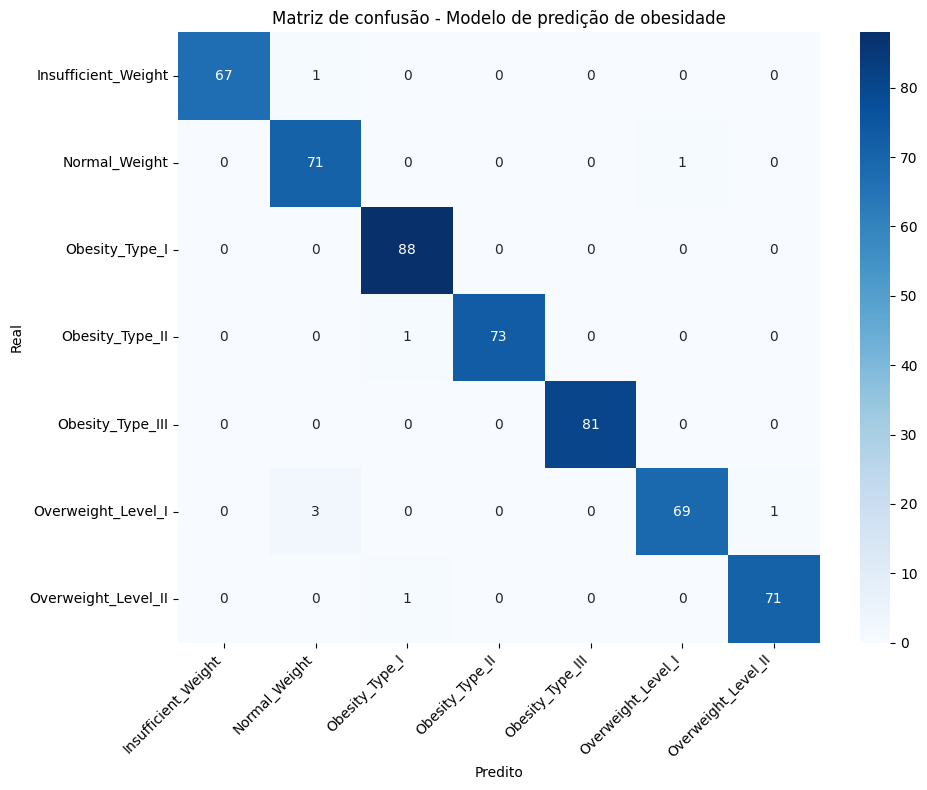

In [86]:
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Matriz de confusão - Modelo de predição de obesidade')
plt.tight_layout()
plt.show()

In [87]:
# Validação cruzada para robustez
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(best_model, X_train_std, y_train, cv=cv, scoring='accuracy')
print('Acurácia (validação cruzada 5-fold):', scores.round(4))
print('Média:', scores.mean().round(4), '| Desvio:', scores.std().round(4))

Acurácia (validação cruzada 5-fold): [0.9811 0.9874 1.     0.9905 0.9842]
Média: 0.9886 | Desvio: 0.0065


## 7. Importância das features

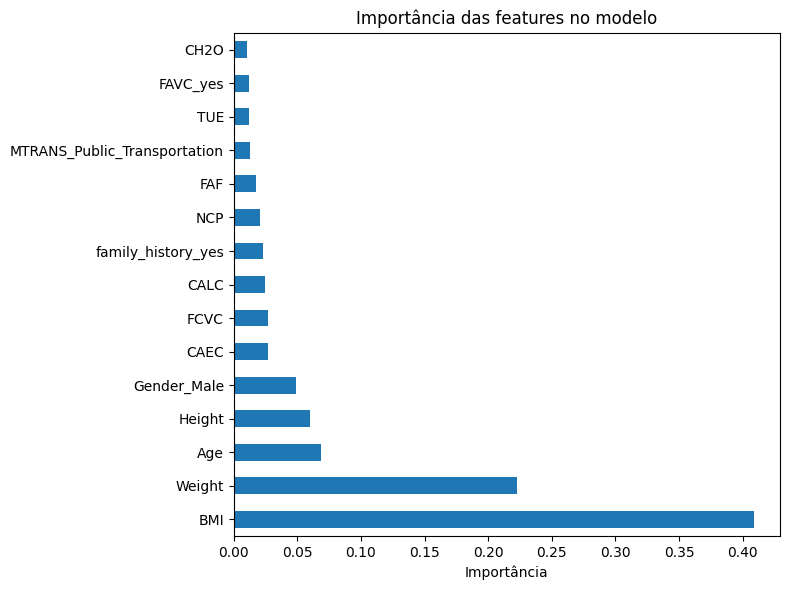

In [88]:
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    imp.head(15).plot(kind='barh', figsize=(8, 6))
    plt.xlabel('Importância')
    plt.title('Importância das features no modelo')
    plt.tight_layout()
    plt.show()

## 8. Sistema preditivo para uso da equipe médica

Função que recebe os dados de um paciente e retorna a classe de obesidade predita.

In [89]:
def prever_obesidade(paciente_dict, model, scaler, num_cols, cat_cols, le_target, feature_names, ordinal_map):
    """
    Prediz a classe de obesidade para um paciente.
    paciente_dict: dicionário com as chaves: Gender, Age, Height, Weight, family_history, FAVC, FCVC, NCP,
                   CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS.
    feature_names: lista de colunas na ordem usada no treino (ex.: list(X.columns)).
    ordinal_map: dicionário para CAEC e CALC (ex.: {'no':0, 'Sometimes':1, 'Frequently':2, 'Always':3}).
    """
    scale_limits = {'FCVC': (1, 3), 'NCP': (1, 4), 'CH2O': (1, 3), 'FAF': (0, 3), 'TUE': (0, 2)}
    paciente = pd.DataFrame([paciente_dict])
    paciente['BMI'] = paciente['Weight'] / (paciente['Height'] ** 2)
    for col, (low, high) in scale_limits.items():
        if col in paciente.columns:
            paciente[col] = np.clip(np.round(paciente[col].astype(float)), low, high).astype(int)
    paciente['CAEC'] = paciente['CAEC'].map(ordinal_map).fillna(0).astype(int)
    paciente['CALC'] = paciente['CALC'].map(ordinal_map).fillna(0).astype(int)
    
    X_num_p = paciente[num_cols]
    X_cat_p = paciente[cat_cols]
    X_cat_p = pd.get_dummies(X_cat_p, drop_first=True, dtype=int)
    
    X_p = pd.concat([X_num_p.reset_index(drop=True), X_cat_p.reset_index(drop=True)], axis=1)
    X_p = X_p.reindex(columns=feature_names, fill_value=0)
    X_p[num_cols] = scaler.transform(X_p[num_cols])
    
    pred_encoded = model.predict(X_p)[0]
    pred_label = le_target.inverse_transform([pred_encoded])[0]
    return pred_label

# Exemplo de uso com um registro do próprio dataset
exemplo = df.drop(columns=['Obesity']).iloc[0].to_dict()
pred_exemplo = prever_obesidade(exemplo, best_model, scaler, num_cols, cat_cols, le_target, list(X.columns), ordinal_map)
print('Exemplo - Classe real:', df['Obesity'].iloc[0])
print('Exemplo - Classe predita:', pred_exemplo)

Exemplo - Classe real: Normal_Weight
Exemplo - Classe predita: Normal_Weight


In [90]:
# Salvando componentes do pipeline para uso em produção
import joblib

pipeline_artifacts = {
    'model': best_model,
    'scaler': scaler,
    'label_encoder': le_target,
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'feature_names': list(X.columns),
    'ordinal_map': ordinal_map
}
joblib.dump(pipeline_artifacts, 'pipeline_obesidade.joblib')
print('Pipeline salvo em pipeline_obesidade.joblib')

Pipeline salvo em pipeline_obesidade.joblib


## Resumo da entrega

- **Pipeline de ML:** Carga → Feature Engineering (BMI, arredondamento de escalas) → Codificação (One-Hot + Label) → Padronização → Treinamento (Random Forest / Gradient Boosting).
- **Assertividade:** Modelo com acurácia **acima de 75%** no conjunto de teste e validada por validação cruzada.
- **Sistema preditivo:** Função `prever_obesidade()` e artefatos salvos em `pipeline_obesidade.joblib` para integração com o sistema do hospital.